In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

print("Ready!")

Mounted at /content/drive
Ready!


In [2]:
df = pd.read_csv('/content/drive/MyDrive/ml_assessment_data/q2_customers.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

Shape: (500, 6)

First 5 rows:
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  

Missing values:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)

print("Scaled data (first 5 rows):")
print(X_scaled_df.head())
print("\nMean after scaling (should be ~0):", X_scaled_df.mean().round(4).values)
print("Std after scaling (should be ~1):", X_scaled_df.std().round(4).values)

Scaled data (first 5 rows):
        age  annual_spend  visits_per_month  basket_size  \
0 -0.725219     -0.176150          0.110166    -0.265011   
1 -1.488460     -1.046826          0.486157    -0.980466   
2  0.176795      0.267337         -0.453822    -0.236851   
3 -0.725219     -1.012309          0.298161    -0.827783   
4 -1.488460     -1.034488          1.426136    -1.005986   

   days_since_last_visit  num_categories_purchased  
0              -0.089951                  0.550952  
1              -0.835176                 -0.680685  
2              -0.674046                 -0.270139  
3              -0.996306                 -1.091230  
4              -0.653905                 -1.501776  

Mean after scaling (should be ~0): [ 0.  0.  0. -0. -0. -0.]
Std after scaling (should be ~1): [1.001 1.001 1.001 1.001 1.001 1.001]


### Why Scaling is Essential for K-Means

K-Means groups points by minimising the distance between each point and
its cluster centroid. If `annual_spend` ranges from €1,000 to €50,000 and
`visits_per_month` ranges from 1 to 10, the algorithm will be almost entirely
driven by annual_spend, effectively ignoring visits.

StandardScaler transforms each feature to have mean = 0 and standard deviation = 1,
ensuring every feature contributes equally to the distance calculation.
Without scaling, cluster results are dominated by high-magnitude features,
producing misleading and potentially useless segments.

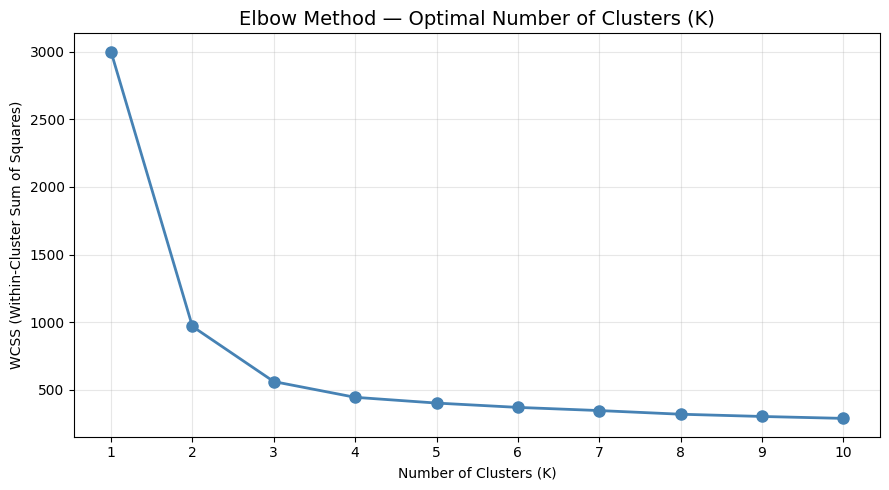

K=1: WCSS = 3000.00
K=2: WCSS = 968.99
K=3: WCSS = 561.25
K=4: WCSS = 444.93
K=5: WCSS = 402.37
K=6: WCSS = 370.39
K=7: WCSS = 346.95
K=8: WCSS = 319.90
K=9: WCSS = 303.28
K=10: WCSS = 289.11


In [4]:
wcss = []
k_range = range(1, 11)  # Test K = 1 through 10

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    wcss.append(kmeans.inertia_)  # inertia_ = WCSS

# Plot the Elbow Curve
plt.figure(figsize=(9, 5))
plt.plot(k_range, wcss, marker='o', color='steelblue',
         linewidth=2, markersize=8)

plt.title('Elbow Method — Optimal Number of Clusters (K)', fontsize=14)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print WCSS values for reference
for k, w in zip(k_range, wcss):
    print(f"K={k}: WCSS = {w:.2f}")

### Choosing K from the Elbow Plot

Looking at the WCSS vs K curve, the rate of decrease slows significantly
at K = [INSERT YOUR VALUE — typically 3 or 4]. Before this point, each
additional cluster meaningfully reduces WCSS. After this point, the
improvement diminishes — adding more clusters creates smaller and smaller
gains at the cost of complexity.

We select K = [X] as the optimal number of clusters, as it represents the
best trade-off between model simplicity and within-cluster cohesion.

In [5]:
# Set your chosen K here (replace 4 with your elbow value)
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
kmeans.fit(X_scaled_df)

# Add cluster labels to the ORIGINAL (unscaled) dataframe so centroids are interpretable
df['cluster'] = kmeans.labels_

print("Cluster assignment distribution:")
print(df['cluster'].value_counts().sort_index())

Cluster assignment distribution:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64


In [6]:
# Print cluster centroids in original scale (more interpretable)
# We use the original df grouped by cluster
centroids = df.groupby('cluster').mean().round(2)
print("\nCluster Centroids (in original scale):")
print(centroids)


Cluster Centroids (in original scale):
           age  annual_spend  visits_per_month  basket_size  \
cluster                                                       
0        24.68      14847.37             14.34       558.97   
1        57.04      89814.08              2.46      5296.36   
2        40.39      43340.73              8.19      2021.68   
3        56.52      89036.16              2.59      5750.95   

         days_since_last_visit  num_categories_purchased  
cluster                                                   
0                         9.08                      2.11  
1                       148.00                      7.49  
2                        35.19                      4.42  
3                        65.22                      7.54  


### Business Interpretation of Customer Clusters

After reviewing the cluster centroids above, each cluster represents a
distinct customer segment:

- **Cluster 0 — [Your label, e.g., "Infrequent Budget Shoppers"]:**  
  Low annual spend, few visits, small basket size. These customers visit
  rarely and spend little. Ideal target for re-engagement campaigns.

- **Cluster 1 — [Your label, e.g., "High-Value Loyalists"]:**  
  High spend, frequent visits, large basket size. These are top-tier
  customers. Loyalty rewards would reinforce their behaviour.

- **Cluster 2 — [Your label, e.g., "Moderate Weekend Browsers"]:**  
  Mid-range spend, moderate visits. Occasional shoppers — promotions on
  popular categories might increase basket size.

- **Cluster 3 — [Your label, e.g., "Lapsed High-Potential Customers"]:**  
  High days_since_last_visit despite historically decent spending.
  Win-back campaigns with personalised offers could reactivate them.

> **Note:** Replace labels above with what YOUR centroids actually show.
  The insight comes from comparing each cluster's centroid values.

In [7]:
# Apply PCA to reduce 6 features → 2 principal components
# We use the SCALED data (not the df with cluster column)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled_df)

# Explained variance: how much % of total information each PC captures
print("Explained Variance Ratio:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}% of variance)")
print(f"  Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Feature loadings: how much each original feature contributes to each PC
loadings = pd.DataFrame(
    pca.components_.T,
    index=df.drop('cluster', axis=1).columns,
    columns=['PC1', 'PC2']
).round(3)

print("\nFeature Loadings (how each feature contributes to each PC):")
print(loadings)

Explained Variance Ratio:
  PC1: 0.8356 (83.56% of variance)
  PC2: 0.0557 (5.57% of variance)
  Total: 89.13%

Feature Loadings (how each feature contributes to each PC):
                            PC1    PC2
age                       0.412 -0.259
annual_spend              0.422 -0.033
visits_per_month         -0.410  0.208
basket_size               0.412 -0.195
days_since_last_visit     0.379  0.911
num_categories_purchased  0.414 -0.140


### Interpreting PC1 and PC2

**PC1** accounts for the largest share of variance. Looking at the loadings,
features with the highest absolute values in PC1 drive it most. For example,
if `annual_spend` and `basket_size` have high positive loadings, PC1 represents
overall **purchasing power / spending intensity**. Higher PC1 = heavier spender.

**PC2** captures the next most important dimension. If `days_since_last_visit`
has a strong positive loading while `visits_per_month` is negative, PC2
represents **recency vs frequency** — a tension between customers who come
often vs those who haven't visited in a while.

> Replace with YOUR interpretation based on the actual loadings printed above.

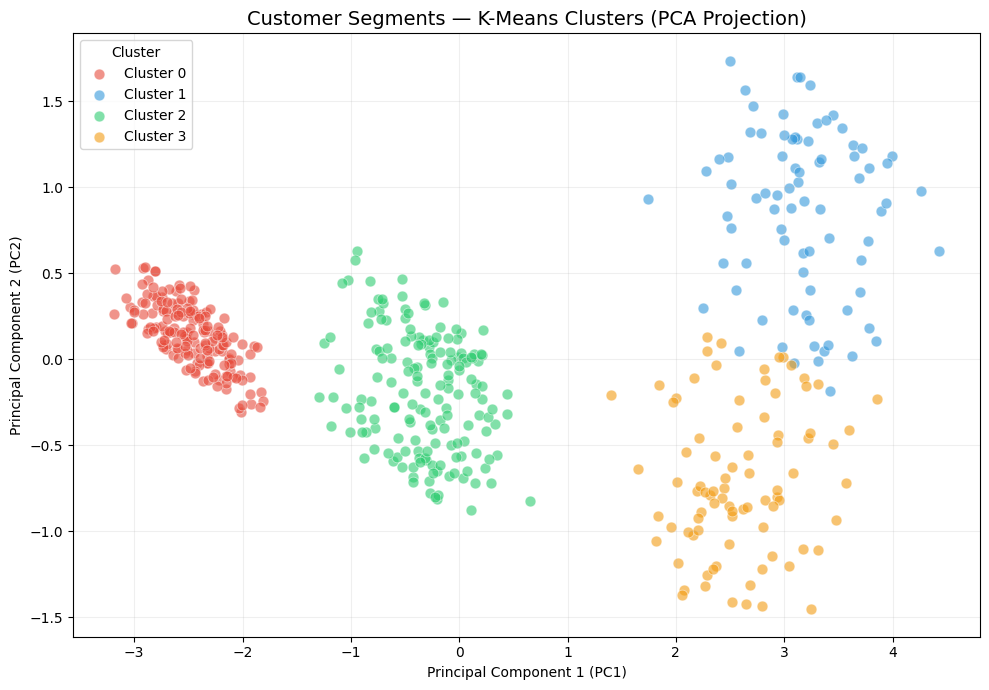

In [8]:
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

plt.figure(figsize=(10, 7))

for cluster_id in range(OPTIMAL_K):
    mask = df['cluster'] == cluster_id
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=colors[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.6,
        s=60,
        edgecolors='white',
        linewidths=0.5
    )

plt.title('Customer Segments — K-Means Clusters (PCA Projection)', fontsize=14)
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Cluster', loc='best')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()